In [12]:
import pandas as pd

# Tu CSV
df_tuyo = pd.read_csv("dataset_entrenable_sentimiento_es.csv")

# CSV de Felipe
df_felipe = pd.read_csv("dataset_modelado_sentimiento_Felipe.csv")


# Renombrar columnas si es necesario
# Suponiendo que en el CSV de Felipe las columnas son 'Frase' y 'Etiqueta'
df_felipe = df_felipe.rename(columns={"Frase": "text_clean", "Etiqueta": "label"})

# Verificar
print("Tu dataset:", df_tuyo.shape)
print("Dataset Felipe:", df_felipe.shape)



Tu dataset: (26255, 3)
Dataset Felipe: (5341, 2)


In [13]:
print("Tu dataset:")
print(df_tuyo.dtypes)
print(df_tuyo.head())

print("\nDataset Felipe:")
print(df_felipe.dtypes)
print(df_felipe.head())

Tu dataset:
text_clean    object
label          int64
len_text       int64
dtype: object
                                          text_clean  label  len_text
0  el fin de semana mi pareja y yo hicimos una re...      0       766
1  calefacción averiada o no operativa se comenta...      0       196
2  este hotel ha bajado notoriamente su categoria...      0       253
3  son pequeños se bloquean y son insuficientes p...      0       259
4  mal mal y mal una enorme diferencia de trato c...      0       676

Dataset Felipe:
clean_text    object
y              int64
dtype: object
                                          clean_text  y
0  el fin de semana mi pareja y yo hicimos una re...  0
1  calefacción averiada o no operativa se comenta...  0
2  este hotel ha bajado notoriamente su categoria...  0
3  son pequeños se bloquean y son insuficientes p...  0
4  mal mal y mal una enorme diferencia de trato c...  0


In [14]:
df_tuyo = df_tuyo.rename(columns={"text_clean": "text_clean", "label": "label"})
df_felipe = df_felipe.rename(columns={"clean_text": "text_clean", "y": "label"})

In [15]:
# Eliminar filas donde label sea NaN
df_tuyo = df_tuyo.dropna(subset=['label'])
df_felipe = df_felipe.dropna(subset=['label'])

# Ahora convertir a int
df_tuyo['label'] = df_tuyo['label'].astype(int)
df_felipe['label'] = df_felipe['label'].astype(int)

In [16]:
df_tuyo = df_tuyo[['text_clean', 'label']]

In [17]:
# Concatenar ambos datasets
df_fusionado = pd.concat([df_tuyo, df_felipe], ignore_index=True)

# Limpiar nulos
df_fusionado.dropna(subset=['text_clean', 'label'], inplace=True)
df_fusionado['label'] = df_fusionado['label'].astype(int)

print("✅ Total filas después de fusionar:", len(df_fusionado))

✅ Total filas después de fusionar: 31596


In [18]:
total_antes = len(df_tuyo) + len(df_felipe)
total_despues = len(df_fusionado)
filas_eliminadas = total_antes - total_despues
print(f"Filas eliminadas por nulos: {filas_eliminadas}")

Filas eliminadas por nulos: 0


In [19]:
print("Columnas y tipos de df_fusionado:")
print(df_fusionado.dtypes)
print(df_fusionado.head())

Columnas y tipos de df_fusionado:
text_clean    object
label          int64
dtype: object
                                          text_clean  label
0  el fin de semana mi pareja y yo hicimos una re...      0
1  calefacción averiada o no operativa se comenta...      0
2  este hotel ha bajado notoriamente su categoria...      0
3  son pequeños se bloquean y son insuficientes p...      0
4  mal mal y mal una enorme diferencia de trato c...      0


In [20]:
# Separar por clase
df_0 = df_fusionado[df_fusionado['label'] == 0]
df_1 = df_fusionado[df_fusionado['label'] == 1]

# Número objetivo para equilibrar
target = len(df_1)  # queremos que 0 ≈ 9655

# Eliminar duplicados de 0 aleatoriamente hasta target
df_0_balanced = df_0.sample(n=target, random_state=42)

# Combinar con la clase 1 completa
df_fusionado_equilibrado = pd.concat([df_0_balanced, df_1], ignore_index=True)

# Mezclar filas
df_fusionado_equilibrado = df_fusionado_equilibrado.sample(frac=1, random_state=42).reset_index(drop=True)

# Revisar conteo final
print(df_fusionado_equilibrado['label'].value_counts())

label
0    15404
1    15404
Name: count, dtype: int64


In [21]:
print("Filas nulas por columna:")
print(df_fusionado_equilibrado.isna().sum())

Filas nulas por columna:
text_clean    0
label         0
dtype: int64


In [22]:
duplicados = df_fusionado_equilibrado.duplicated().sum()
print("Número de filas duplicadas en df_fusionado_equilibrado:", duplicados)

Número de filas duplicadas en df_fusionado_equilibrado: 5125


In [23]:
print("Conteo de etiquetas:")
print(df_fusionado_equilibrado['label'].value_counts())

Conteo de etiquetas:
label
0    15404
1    15404
Name: count, dtype: int64


In [24]:
# Ensure df_fusionado_equilibrado is defined before exporting
# This code block re-creates df_fusionado_equilibrado if it's not already in the session
import pandas as pd

if 'df_fusionado_equilibrado' not in locals():
    # Assuming df_fusionado has been previously defined and is available
    # Re-run the balancing logic from cell 6nfZXLqvHkcV or 6D1ds9x7IigT
    df_0 = df_fusionado[df_fusionado['label'] == 0]
    df_1 = df_fusionado[df_fusionado['label'] == 1]

    target = len(df_1)
    df_0_balanced = df_0.sample(n=target, random_state=42)
    df_fusionado_equilibrado = pd.concat([df_0_balanced, df_1], ignore_index=True)
    df_fusionado_equilibrado = df_fusionado_equilibrado.sample(frac=1, random_state=42).reset_index(drop=True)

df_fusionado_equilibrado.to_csv('df_fusionado_equilibrado.csv', index=False)
print("DataFrame 'df_fusionado_equilibrado' exportado a 'df_fusionado_equilibrado.csv'")

DataFrame 'df_fusionado_equilibrado' exportado a 'df_fusionado_equilibrado.csv'


In [26]:
import pandas as pd

# Leer CSVs
df_inicial = pd.read_csv("df_fusionado_equilibrado.csv")
df_5000 = pd.read_csv("frases_5000_sentimientos.csv")

# Renombrar columnas para que coincidan
df_inicial = df_inicial.rename(columns={"text_clean": "text_clean", "label": "label"})
df_5000 = df_5000.rename(columns={"texto": "text_clean", "label": "label"})

# Limpiar datos
df_inicial['text_clean'] = df_inicial['text_clean'].astype(str).str.strip()
df_5000['text_clean'] = df_5000['text_clean'].astype(str).str.strip()

df_inicial['label'] = pd.to_numeric(df_inicial['label'], errors='coerce')
df_5000['label'] = pd.to_numeric(df_5000['label'], errors='coerce')

# Concatenar
df_fusionado_enriquecido = pd.concat([df_inicial, df_5000], ignore_index=True)

# Limpiar filas inválidas
df_fusionado_enriquecido = df_fusionado_enriquecido.dropna(subset=['text_clean', 'label'])
df_fusionado_enriquecido['label'] = df_fusionado_enriquecido['label'].astype(int)

print("✅ Total filas después de fusionar:", len(df_fusionado_enriquecido))



✅ Total filas después de fusionar: 35808


✅ Conteo de clases después del balanceo:
label
1    17904
0    17904
Name: count, dtype: int64
✅ Conjuntos de entrenamiento y prueba listos
Filas entrenamiento: 28646
Filas prueba: 7162
✅ Modelo fusionado entrenado
Accuracy: 0.8906729963697291

Classification Report:
               precision    recall  f1-score   support

    NEGATIVO       0.89      0.89      0.89      3581
    POSITIVO       0.89      0.89      0.89      3581

    accuracy                           0.89      7162
   macro avg       0.89      0.89      0.89      7162
weighted avg       0.89      0.89      0.89      7162



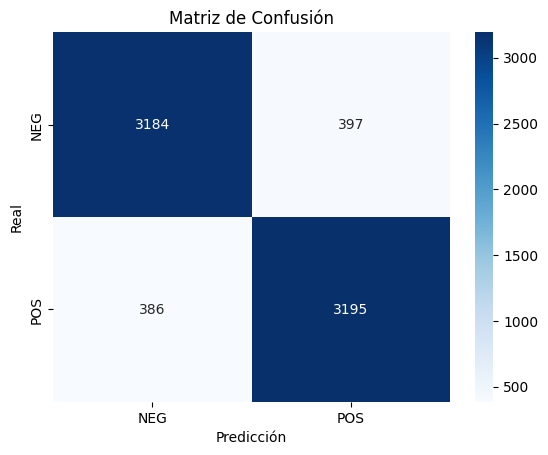

✅ Modelo guardado como 'modelo_fusionado_sentimientos.pk1'


In [27]:
# -----------------------------
# 1️⃣ Balancear clases
# -----------------------------
import pandas as pd

# Usar df_fusionado_enriquecido directamente
df_fusionado = df_fusionado_enriquecido

# Separar por clase
df_0 = df_fusionado[df_fusionado['label'] == 0]
df_1 = df_fusionado[df_fusionado['label'] == 1]

# Número objetivo: igualar a la clase minoritaria
target = len(df_1)

# Eliminar duplicados aleatoriamente de la clase 0 para equilibrar
df_0_equilibrado = df_0.sample(n=target, random_state=42)

# Combinar con la clase 1 completa
df_fusionado_equilibrado = pd.concat([df_0_equilibrado, df_1], ignore_index=True)

# Mezclar filas
df_fusionado_equilibrado = df_fusionado_equilibrado.sample(frac=1, random_state=42).reset_index(drop=True)

# Revisar conteo final
print("✅ Conteo de clases después del balanceo:")
print(df_fusionado_equilibrado['label'].value_counts())

# -----------------------------
# 2️⃣ Separar entrenamiento y prueba
# -----------------------------
from sklearn.model_selection import train_test_split

X = df_fusionado_equilibrado['text_clean']
y = df_fusionado_equilibrado['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Conjuntos de entrenamiento y prueba listos")
print("Filas entrenamiento:", len(X_train))
print("Filas prueba:", len(X_test))

# -----------------------------
# 3️⃣ Crear pipeline TF-IDF + Logistic Regression
# -----------------------------
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline_fusionado = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=5)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# -----------------------------
# 4️⃣ Entrenar modelo
# -----------------------------
pipeline_fusionado.fit(X_train, y_train)
print("✅ Modelo fusionado entrenado")

# -----------------------------
# 5️⃣ Evaluar modelo
# -----------------------------
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = pipeline_fusionado.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["NEGATIVO", "POSITIVO"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["NEG", "POS"], yticklabels=["NEG", "POS"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# -----------------------------
# 6️⃣ Guardar modelo final
# -----------------------------
import joblib
joblib.dump(pipeline_fusionado, "modelo_fusionado_sentimientos.pk1")
print("✅ Modelo guardado como 'modelo_fusionado_sentimientos.pk1'")


In [28]:
# Lista de textos para probar
textos_prueba = [
   "pésimo servicio",
   "muy desordenado",
   "excelente atención",
   "muy fome",
]

# Predecir etiquetas y probabilidades
predicciones = pipeline_fusionado.predict(textos_prueba)
probabilidades = pipeline_fusionado.predict_proba(textos_prueba)

# Mostrar resultados con el mismo formato del proyecto de Felipe
for texto, pred, proba in zip(textos_prueba, predicciones, probabilidades):
    dict_grafico = {"POSITIVO 😊 ✅": proba[1], "NEGATIVO 😟 ❌": proba[0]}
    etiqueta = "POSITIVO" if pred == 1 else "NEGATIVO"
    print(f"Texto: {texto}")
    print(f"Predicción: {etiqueta}")
    print(f"Probabilidades: {dict_grafico}\n")


Texto: pésimo servicio
Predicción: NEGATIVO
Probabilidades: {'POSITIVO 😊 ✅': np.float64(0.20813079676780613), 'NEGATIVO 😟 ❌': np.float64(0.7918692032321939)}

Texto: muy desordenado
Predicción: POSITIVO
Probabilidades: {'POSITIVO 😊 ✅': np.float64(0.9731536955950236), 'NEGATIVO 😟 ❌': np.float64(0.026846304404976373)}

Texto: excelente atención
Predicción: POSITIVO
Probabilidades: {'POSITIVO 😊 ✅': np.float64(0.9987660603596809), 'NEGATIVO 😟 ❌': np.float64(0.0012339396403191483)}

Texto: muy fome
Predicción: POSITIVO
Probabilidades: {'POSITIVO 😊 ✅': np.float64(0.9731536955950236), 'NEGATIVO 😟 ❌': np.float64(0.026846304404976373)}



In [30]:
import pandas as pd

# Archivos y su label correspondiente
archivos = {
    "lexico_negativo_es.csv": 0,
    "palabras_negativas_es.csv": 0,
    "lexico_positivo_es.csv": 1,
    "palabras_positivas_es.csv": 1
}

dfs = []

for archivo, label in archivos.items():
    df = pd.read_csv(archivo)

    # Asegurar columna 'text_clean'
    if 'text' in df.columns:
        df.rename(columns={'text':'text_clean'}, inplace=True)
    elif 'palabra' in df.columns:
        df.rename(columns={'palabra':'text_clean'}, inplace=True)

    # Asignar label explícitamente
    df['label'] = label

    # Eliminar filas con valores faltantes
    df = df.dropna(subset=['text_clean', 'label'])

    dfs.append(df[['text_clean','label']])  # mantener solo columnas necesarias

# Concatenar todos los DataFrames
df_palabras = pd.concat(dfs, ignore_index=True)

print("Filas de palabras clave cargadas:", len(df_palabras))
print(df_palabras.head())

Filas de palabras clave cargadas: 109
                    text_clean  label
0              pésimo servicio      0
1         muy mala experiencia      0
2                  no funcionó      0
3               todo salió mal      0
4  atención lenta y deficiente      0


In [ ]:
df_palabras['label'] = df_palabras['label'].astype(int)

Filas totales después de agregar palabras clave: 35917
✅ Conjuntos de entrenamiento y prueba listos
Filas entrenamiento: 28733
Filas prueba: 7184
✅ Modelo final entrenado con palabras clave
Accuracy: 0.8890590200445434

Classification Report:
               precision    recall  f1-score   support

    NEGATIVO       0.89      0.89      0.89      3591
    POSITIVO       0.89      0.89      0.89      3593

    accuracy                           0.89      7184
   macro avg       0.89      0.89      0.89      7184
weighted avg       0.89      0.89      0.89      7184



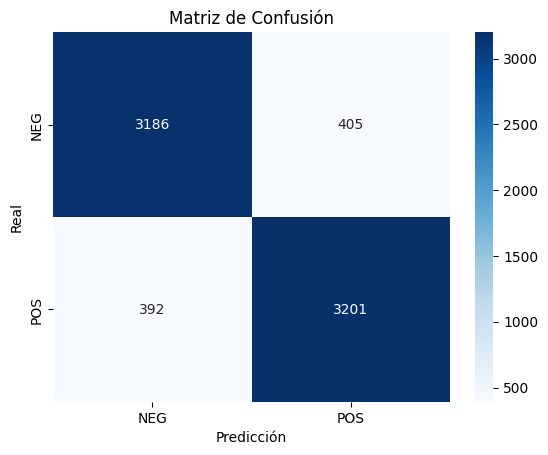

✅ Modelo guardado como 'modelo_fusionado_final_palabras_clave.pk1'


In [31]:
# -----------------------------
# 1️⃣ Unir palabras clave con dataset fusionado y equilibrado
# -----------------------------
df_final = pd.concat([df_fusionado_equilibrado, df_palabras], ignore_index=True)
print("Filas totales después de agregar palabras clave:", len(df_final))

# -----------------------------
# 2️⃣ Separar en entrenamiento y prueba
# -----------------------------
from sklearn.model_selection import train_test_split

X = df_final['text_clean']
y = df_final['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Conjuntos de entrenamiento y prueba listos")
print("Filas entrenamiento:", len(X_train))
print("Filas prueba:", len(X_test))

# -----------------------------
# 3️⃣ Crear y entrenar pipeline TF-IDF + Logistic Regression
# -----------------------------
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_final.fit(X_train, y_train)
print("✅ Modelo final entrenado con palabras clave")

# -----------------------------
# 4️⃣ Evaluar modelo
# -----------------------------
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = pipeline_final.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["NEGATIVO", "POSITIVO"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["NEG", "POS"], yticklabels=["NEG", "POS"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# -----------------------------
# 5️⃣ Guardar modelo final
# -----------------------------
import joblib
joblib.dump(pipeline_final, "modelo_fusionado_final_palabras_clave.pk1")
print("✅ Modelo guardado como 'modelo_fusionado_final_palabras_clave.pk1'")


In [32]:
import pandas as pd

# Cargar CSV
ruta_csv = "frases_5000_sentimientos.csv"
df_frases = pd.read_csv(ruta_csv)

# Revisar las primeras filas
print(df_frases.head())
print(f"Filas totales: {len(df_frases)}")
print(df_frases['label'].value_counts())

                      texto  label
0  Frase positiva ejemplo 1      1
1  Frase positiva ejemplo 2      1
2  Frase positiva ejemplo 3      1
3  Frase positiva ejemplo 4      1
4  Frase positiva ejemplo 5      1
Filas totales: 5000
label
1    2500
0    2500
Name: count, dtype: int64


In [33]:
import pandas as pd
import joblib

# --- Cargar dataset del robot actual ---
ROBOT_PATH = "modelo_fusionado_final_palabras_clave.pk1"
pipeline_fusionado = joblib.load(ROBOT_PATH)

# Suponemos que tu pipeline tiene el modelo y vectorizador así:
vectorizer = pipeline_fusionado.named_steps['tfidf']
model = pipeline_fusionado.named_steps['clf']

# --- Cargar CSV de nuevas frases ---
df_nuevas = pd.read_csv("frases_5000_sentimientos.csv")
print(f"Nuevas frases: {len(df_nuevas)}")
print(df_nuevas['label'].value_counts())

# --- Cargar dataset histórico del robot (si quieres usarlo) ---
# Si tienes un CSV de entrenamiento original o feedback:
# df_actual = pd.read_csv("dataset_modelado_sentimiento.csv")
# O podemos tomar solo los datos internos del robot si lo tenemos:
# Por ahora vamos a usar solo las 5000 nuevas frases para reforzar

# --- Fusionar datasets (en este caso solo reforzando las 5000) ---
df_fusionado = df_nuevas.copy()

# --- Preparar datos para entrenamiento ---
X = df_fusionado['texto'].astype(str)  # Changed 'text_clean' and 'text' to 'texto'
y = df_fusionado['label'].astype(int)

# --- Vectorizar y reentrenar ---
X_vec = vectorizer.fit_transform(X)
model.fit(X_vec, y)

# --- Guardar pipeline reforzado ---
from sklearn.pipeline import Pipeline

pipeline_reforzado = Pipeline([
    ('tfidf', vectorizer),
    ('clf', model)
])

NUEVO_MODELO_PATH = "R5K_v1.pk1"
joblib.dump(pipeline_reforzado, NUEVO_MODELO_PATH) # Changed pipeline_fusionado to pipeline_reforzado

print(f"✅ Modelo guardado como '{NUEVO_MODELO_PATH}'")

Nuevas frases: 5000
label
1    2500
0    2500
Name: count, dtype: int64
✅ Modelo guardado como 'R5K_v1.pk1'


Reentrenar modelo R5K_v1.pk1


In [34]:
import joblib
from sklearn.pipeline import Pipeline

R5K_v1_PATH = "/content/drive/MyDrive/Colab Notebooks/R5K_v1.pk1"
pipeline = joblib.load(R5K_v1_PATH)
vectorizer = pipeline.named_steps['tfidf']
model = pipeline.named_steps['clf']


In [51]:
import pandas as pd

# Nuevos datos para v2
DATASET_REFUERZO = "/content/entrenamiento_10k_completo.csv"

df_refuerzo = pd.read_csv(DATASET_REFUERZO)  # debe tener columnas 'clean_text' y 'y'

# Renombrar columnas para que coincidan con lo esperado
df_refuerzo = df_refuerzo.rename(columns={'frase': 'clean_text', 'sentimiento': 'y'})

# Convertir la columna 'y' a numérico, forzando errores a NaN, luego eliminar nulos
df_refuerzo['y'] = pd.to_numeric(df_refuerzo['y'], errors='coerce')
df_refuerzo.dropna(subset=['clean_text','y'], inplace=True)

# Ahora convertir a int
df_refuerzo['y'] = df_refuerzo['y'].astype(int)

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Supongamos que df_refuerzo ya está correctamente cargado y limpio

X = df_refuerzo['clean_text'].astype(str)
y = df_refuerzo['y']

# Ajustar test_size para asegurarnos de que haya ejemplos de ambas clases
test_size = 0.2  # 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    stratify=y,
    random_state=42
)

# Vectorizador mejorado
vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Modelo robusto
classifier = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    C=1.5,
    max_iter=200
)

# Pipeline final
pipeline_v2 = Pipeline([
    ("tfidf", vectorizer),
    ("clf", classifier)
])

# Entrenamiento
pipeline_v2.fit(X_train, y_train)

# Evaluación
y_pred = pipeline_v2.predict(X_test)

print("\n📊 REPORTE DE CLASIFICACIÓN:\n")
print(classification_report(y_test, y_pred, digits=4))

print("\n🧩 MATRIZ DE CONFUSIÓN:\n")
print(confusion_matrix(y_test, y_pred))

# Guardado final
MODEL_OUT = "/content/R5K_v2.pk1"
joblib.dump(pipeline_v2, MODEL_OUT)

print(f"\n✅ MODELO GUARDADO COMO: {MODEL_OUT}")



📊 REPORTE DE CLASIFICACIÓN:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1000
           1     1.0000    1.0000    1.0000      1000

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000


🧩 MATRIZ DE CONFUSIÓN:

[[1000    0]
 [   0 1000]]

✅ MODELO GUARDADO COMO: /content/R5K_v2.pk1


In [53]:
print(df_refuerzo.shape)
print(df_refuerzo['y'].value_counts())


(10000, 2)
y
0    5000
1    5000
Name: count, dtype: int64


In [55]:
pipeline = joblib.load("/content/R5K_v2.pk1")

tests = [
    "muy fome",
    "ni fu ni fa",
    "todo medio charcha",
    "no volvería ni loco",
    "excelente atención",
    "más o menos",
    "meh"
]

for t in tests:
    p = pipeline.predict_proba([t])[0]
    pred = pipeline.predict([t])[0]
    print(t)
    print("Predicción:", "POSITIVO" if pred==1 else "NEGATIVO")
    print("Prob:", p, "\n")


muy fome
Predicción: NEGATIVO
Prob: [0.76706779 0.23293221] 

ni fu ni fa
Predicción: POSITIVO
Prob: [0.49197553 0.50802447] 

todo medio charcha
Predicción: POSITIVO
Prob: [0.47367219 0.52632781] 

no volvería ni loco
Predicción: NEGATIVO
Prob: [0.99131662 0.00868338] 

excelente atención
Predicción: POSITIVO
Prob: [0.49197553 0.50802447] 

más o menos
Predicción: POSITIVO
Prob: [0.49197553 0.50802447] 

meh
Predicción: POSITIVO
Prob: [0.49197553 0.50802447] 

